In [1]:
# !pip install pgmpy, nah this one doesn't do what I want
!pip install PyDTMC

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from pydtmc import MarkovChain, plot_graph
from itertools import accumulate

%matplotlib inline

In [3]:
# Define state space
STATE_SPACE = ["00", "01", "10", "11", "20", "21"]


def construct_mc(p=0.02, s=0.01, m=0.03, l=0.01):
    """Construct Markov chain.

    p: initial state prep error
    s: state bit-flip error
    m: measurement error
    l: leakage error
    """
    # Define edge matrix
    # Each row represents a set of transitions with the same weight
    # Each element in a row is the destination state for the transition from the column index
    edge_matrix = np.array(
        [
            [0, 0, 3, 3, 5, 5],  # (1-s)(1-m)(1-l)
            [0, 0, 5, 5, 5, 5],  # (1-s)(1-m)l
            [1, 1, 2, 2, 4, 4],  # (1-s)m(1-l)
            [1, 1, 4, 4, 4, 4],  # (1-s)ml
            [3, 3, 0, 0, 5, 5],  # s(1-m)(1-l)
            [5, 5, 0, 0, 5, 5],  # s(1-m)l
            [2, 2, 1, 1, 4, 4],  # sm(1-l)
            [4, 4, 1, 1, 4, 4],  # sml
        ]
    )
    # Define weights for each row
    weights = [
        (1 - s) * (1 - m) * (1 - l),
        (1 - s) * (1 - m) * l,
        (1 - s) * m * (1 - l),
        (1 - s) * m * l,
        s * (1 - m) * (1 - l),
        s * (1 - m) * l,
        s * m * (1 - l),
        s * m * l,
    ]
    # Construct transition matrix
    transition_matrix = np.zeros((6, 6))
    for weight, edges in zip(weights, edge_matrix):
        for from_state, to_state in enumerate(edges):
            transition_matrix[from_state, to_state] += weight

    # Add initial state
    transition_matrix_with_initial = np.vstack((transition_matrix, np.zeros(6)))
    transition_matrix_with_initial = np.hstack(
        (transition_matrix_with_initial, np.zeros((7, 1)))
    )
    transition_matrix_with_initial[-1, 0] = 1 - p
    transition_matrix_with_initial[-1, 2] = p
    mc = MarkovChain(transition_matrix_with_initial, STATE_SPACE + ["N"])
    return mc


def get_expected_z(state):
    """<Z> given by classical bit outcome."""
    return (state[0] + state[2] + state[4]) - (state[1] + state[3] + state[5])

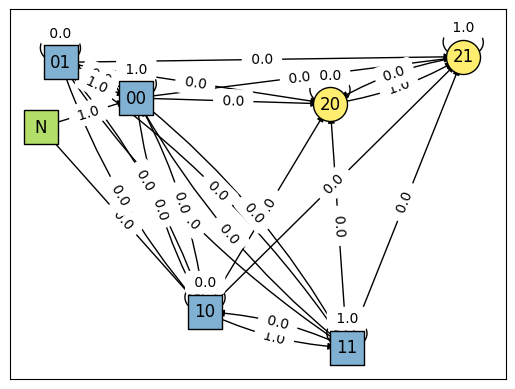

In [4]:
# # Plot Markov Chain graph
mc = construct_mc()
plot_graph(mc, force_standard=True)

In [10]:
def plot_markov_chain(p, s, m, l, num_steps=300):
    mc = construct_mc(p, s, m, l)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 5))

    # Plot transition matrix
    im = ax1.imshow(mc.p, cmap="viridis")
    ax1.set_title("Transition Matrix")
    ax1.set_xlabel("To State")
    ax1.set_ylabel("From State")
    fig.colorbar(im, ax=ax1)

    # Plot state distribution probabilities
    num_steps = int(num_steps)
    distributions = mc.redistribute(num_steps, initial_status="N", output_last=False)
    distributions = np.array(distributions)[1:]
    ax2.stackplot(range(num_steps), distributions.T[:-1], labels=STATE_SPACE)
    ax2.set_title("State Distribution Probabilities")
    ax2.set_xlabel("Steps")
    ax2.set_ylabel("Probability")
    ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    # Plot <Z> vs steps
    z_values = [get_expected_z(d[:-1]) for d in distributions]
    ax3.plot(z_values, marker="o")

    # also get z-parity, by accumulating parity
    def xor(a, b):
        # this function is defined over [0,1]
        # but <Z> is [-1, 1]
        # so I transform into [0,1] and back
        a = a / 2 + 0.5
        b = b / 2 + 0.5
        z = a + b - a * b * (1 + a + b - a * b)
        return (z - 0.5) * 2

    parity_z = abs(np.array(list((accumulate(z_values, xor)))))
    ax3.plot(parity_z, marker="o")

    ax3.set_xlabel("Steps")
    ax3.set_ylabel("<Z>")
    ax3.set_title("<Z> vs Steps")

    fig.tight_layout()


# Create interactive sliders
interact(
    plot_markov_chain,
    p=FloatSlider(min=0, max=0.25, step=0.001, value=0.02, description="p:"),
    s=FloatSlider(min=0, max=0.1, step=0.001, value=0.01, description="s:"),
    m=FloatSlider(min=0, max=0.1, step=0.001, value=0.03, description="m:"),
    l=FloatSlider(min=0, max=0.1, step=0.001, value=0.01, description="l:"),
    num_steps=FloatSlider(min=10, max=300, step=10, value=300, description="Steps:"),
);

interactive(children=(FloatSlider(value=0.02, description='p:', max=0.25, step=0.001), FloatSlider(value=0.01,…